<a href="https://colab.research.google.com/github/DeepFluxion/Mack_2026_Data_Science_Expirience/blob/main/notebooks/Aula_2_bank_marketing_eda_Parte_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 AULA 2 - EDA Completa — Bank Marketing (UCI)
## Otimização de Custos em Call Centers com Ciência de Dados

---
**Dataset:** Bank Marketing — UCI Machine Learning Repository  
**Versão:** `bank-additional-full.csv` — 41.188 instâncias | 20 features + 1 target  
**Período:** Maio/2008 a Novembro/2010 (Banco Português de Varejo)  
**Referência:** Moro et al. (2014) — *A Data-Driven Approach to Predict the Success of Bank Telemarketing*

---
### 🎯 Objetivo do Projeto
Um banco de varejo português precisa **vender depósitos a prazo** via call center.  
Ligar para toda a base é caro e ineficiente. Usando EDA e posterior modelagem preditiva,  
buscamos identificar **quais clientes têm maior probabilidade de conversão** antes de discar.

**Pergunta-chave:** *O cliente irá ou não assinar um depósito a prazo? (`y = 'yes'` ou `'no'`)*

---
### 🗺️ Roteiro do Notebook
1. Configuração do Ambiente
2. Carga e Visão Geral dos Dados
3. Análise Univariada — Variável Alvo
4. Análise Univariada — Variáveis Numéricas
5. Análise Univariada — Variáveis Categóricas
6. Análise Bivariada — Features × Target
7. Matriz de Correlação
8. Síntese dos Insights

---
## 1. ⚙️ Configuração Inicial

Importamos as bibliotecas essenciais do ecossistema Python para análise de dados e visualização.

| Biblioteca | Papel |
|---|---|
| `pandas` | Manipulação e análise de DataFrames |
| `numpy` | Operações numéricas e vetorização |
| `matplotlib` | Motor base de plotagem |
| `seaborn` | Visualizações estatísticas de alto nível |
| `warnings` | Suprimir avisos irrelevantes para a aula |

In [2]:
# ============================================================
# CÉLULA 1 — Imports e configuração global de estilo
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

# Suprime avisos desnecessários
warnings.filterwarnings('ignore')

# Tema global do seaborn — fundo branco com grid sutil
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Resolução dos gráficos (importante para apresentações em MBA)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Paleta de cores do projeto (vermelho + cinza, estilo do material)
COR_NO  = '#4A4A4A'   # cinza escuro → clientes que NÃO assinaram
COR_YES = '#D62728'   # vermelho     → clientes que ASSINARAM
PALETA_TARGET = [COR_NO, COR_YES]

print('✅ Ambiente configurado com sucesso!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Ambiente configurado com sucesso!
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


---
## 2. 📂 Carga e Visão Geral dos Dados

### 2.1 Leitura do arquivo
O arquivo usa **ponto e vírgula** como separador (padrão europeu de CSV).  
Usamos `sep=';'` para informar ao pandas o delimitador correto.

> **⚠️ Nota sobre a versão:** Estamos usando `bank-additional-full.csv`, a versão enriquecida  
> com 5 indicadores macroeconômicos adicionais (emprego, inflação, juros Euribor, etc.)  
> que aumentam substancialmente o poder preditivo dos modelos.

In [3]:
# ============================================================
# CÉLULA 2 — Leitura do dataset
# ============================================================

# Ajuste o caminho conforme necessário (Google Colab: '/content/...')
#CAMINHO = 'bankadditionalfull.csv'
CAMINHO ='https://raw.githubusercontent.com/DeepFluxion/Mack_2026_Data_Science_Expirience/refs/heads/main/data/bank-additional-full.csv'
df = pd.read_csv(CAMINHO, sep=';')

print(f'✅ Dataset carregado com sucesso!')
print(f'   Linhas  : {df.shape[0]:,}')
print(f'   Colunas : {df.shape[1]}')
print()
print('Primeiras 5 linhas:')
df.head()

✅ Dataset carregado com sucesso!
   Linhas  : 41,188
   Colunas : 21

Primeiras 5 linhas:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 2.2 Estrutura e Tipos de Dados

`df.info()` é o **raio-X** do DataFrame: mostra tipos de dados, contagem de não-nulos e uso de memória.  
É o primeiro passo para detectar colunas com tipos errados ou com missing values.

In [4]:
# ============================================================
# CÉLULA 3 — Info e tipos
# ============================================================
print('=== df.info() ===')
df.info()
print()

# Verificação de valores 'unknown' (missing disfarçado)
print('=== Contagem de "unknown" por coluna ===')
unknown_counts = {col: (df[col] == 'unknown').sum()
                  for col in df.select_dtypes('object').columns}
unknown_df = pd.DataFrame.from_dict(unknown_counts, orient='index',
                                     columns=['qtd_unknown'])
unknown_df['pct_unknown'] = (unknown_df['qtd_unknown'] / len(df) * 100).round(2)
unknown_df[unknown_df['qtd_unknown'] > 0].sort_values('qtd_unknown', ascending=False)

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx

,qtd_unknown,pct_unknown
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


### 2.3 Estatísticas Descritivas

`df.describe()` resume a **distribuição estatística** de cada variável numérica:  
média, desvio-padrão, quartis (Q1, mediana, Q3) e valores extremos (min/max).

**O que observar:**
- `pdays`: valor 999 significa "cliente não foi contactado anteriormente" — é um código especial, não um número real
- `duration`: desvio-padrão alto indica forte assimetria à direita (outliers de chamadas muito longas)
- `campaign`: maioria das ligações é pequena, mas há casos extremos (outliers)

In [5]:
# ============================================================
# CÉLULA 4 — Estatísticas descritivas
# ============================================================

# Transposta para caber melhor na tela
desc = df.describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(1)  # coeficiente de variação
desc.style.background_gradient(cmap='RdYlGn_r', subset=['cv%'])

,count,mean,std,min,25%,50%,75%,max,cv%
age,41188.000000,40.024060,10.421250,17.000000,32.000000,38.000000,47.000000,98.000000,26.000000
duration,41188.000000,258.285010,259.279249,0.000000,102.000000,180.000000,319.000000,4918.000000,100.400000
campaign,41188.000000,2.567593,2.770014,1.000000,1.000000,2.000000,3.000000,56.000000,107.900000
pdays,41188.000000,962.475454,186.910907,0.000000,999.000000,999.000000,999.000000,999.000000,19.400000
previous,41188.000000,0.172963,0.494901,0.000000,0.000000,0.000000,0.000000,7.000000,286.100000
emp.var.rate,41188.000000,0.081886,1.570960,-3.400000,-1.800000,1.100000,1.400000,1.400000,1918.500000
cons.price.idx,41188.000000,93.575664,0.578840,92.201000,93.075000,93.749000,93.994000,94.767000,0.600000
cons.conf.idx,41188.000000,-40.502600,4.628198,-50.800000,-42.700000,-41.800000,-36.400000,-26.900000,-11.400000
euribor3m,41188.000000,3.621291,1.734447,0.634000,1.344000,4.857000,4.961000,5.045000,47.900000
nr.employed,41188.000000,5167.035911,72.251528,4963.600000,5099.100000,5191.000000,5228.100000,5228.100000,1.400000


---
## 3. 🎯 Análise Univariada — Variável Alvo (`y`)

Antes de qualquer análise, precisamos entender **o que queremos prever** e qual é a proporção das classes.  
Um forte desbalanceamento entre classes é uma das principais armadilhas em projetos de ML para bancos.

> **Regra de ouro:** Se a classe minoritária for < 15% do total, precisaremos de técnicas  
> de balanceamento (SMOTE, class_weight, etc.) antes de treinar qualquer modelo.

=== Distribuição da Variável Alvo ===
   no: 36,548 clientes  (88.7%)
  yes:  4,640 clientes  (11.3%)


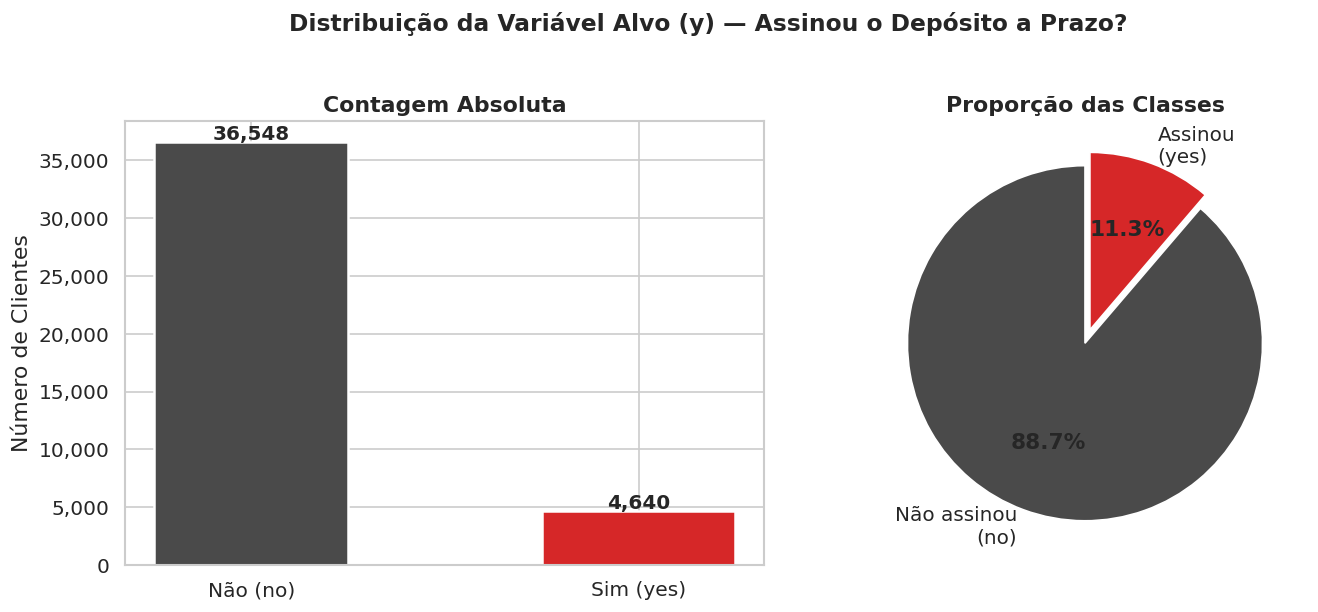


⚠️  DESBALANCEAMENTO: Para cada cliente que assinou, há 7.9 que não assinaram.
   → Isso exige atenção especial na etapa de modelagem (métricas, threshold, SMOTE).


In [6]:
# ============================================================
# CÉLULA 5 — Distribuição da variável alvo
# ============================================================

contagem_y = df['y'].value_counts()
pct_y      = df['y'].value_counts(normalize=True) * 100

print('=== Distribuição da Variável Alvo ===')
for cat in ['no', 'yes']:
    print(f'  {cat:>3}: {contagem_y[cat]:>6,} clientes  ({pct_y[cat]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribuição da Variável Alvo (y) — Assinou o Depósito a Prazo?',
             fontsize=14, fontweight='bold', y=1.02)

# Gráfico 1: Contagem absoluta
ax = axes[0]
bars = ax.bar(['Não (no)', 'Sim (yes)'], contagem_y[['no','yes']],
              color=PALETA_TARGET, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Contagem Absoluta', fontweight='bold')
ax.set_ylabel('Número de Clientes')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Rótulo nas barras
for bar, val in zip(bars, contagem_y[['no','yes']]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontweight='bold', fontsize=12)

# Gráfico 2: Pizza com proporção
ax2 = axes[1]
explode = (0, 0.08)
wedges, texts, autotexts = ax2.pie(
    pct_y[['no','yes']],
    labels=['Não assinou\n(no)', 'Assinou\n(yes)'],
    autopct='%1.1f%%',
    colors=PALETA_TARGET,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
ax2.set_title('Proporção das Classes', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_01_target_distribution.png', dpi=150)
plt.show()

ratio = contagem_y['no'] / contagem_y['yes']
print(f'\n⚠️  DESBALANCEAMENTO: Para cada cliente que assinou, há {ratio:.1f} que não assinaram.')
print('   → Isso exige atenção especial na etapa de modelagem (métricas, threshold, SMOTE).')

---
## 4. 📊 Análise Univariada — Variáveis Numéricas

Para cada variável numérica, usamos dois gráficos complementares:

| Gráfico | O que revela |
|---|---|
| **Histograma** | Forma da distribuição (normal, assimétrica, bimodal) |
| **Boxplot** | Mediana, quartis e outliers matemáticos (±1.5×IQR) |

**Variáveis numéricas do dataset:**
- **Perfil do cliente:** `age` (idade)
- **Campanha atual:** `duration`, `campaign`, `pdays`, `previous`
- **Indicadores macro:** `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`

Variáveis numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']



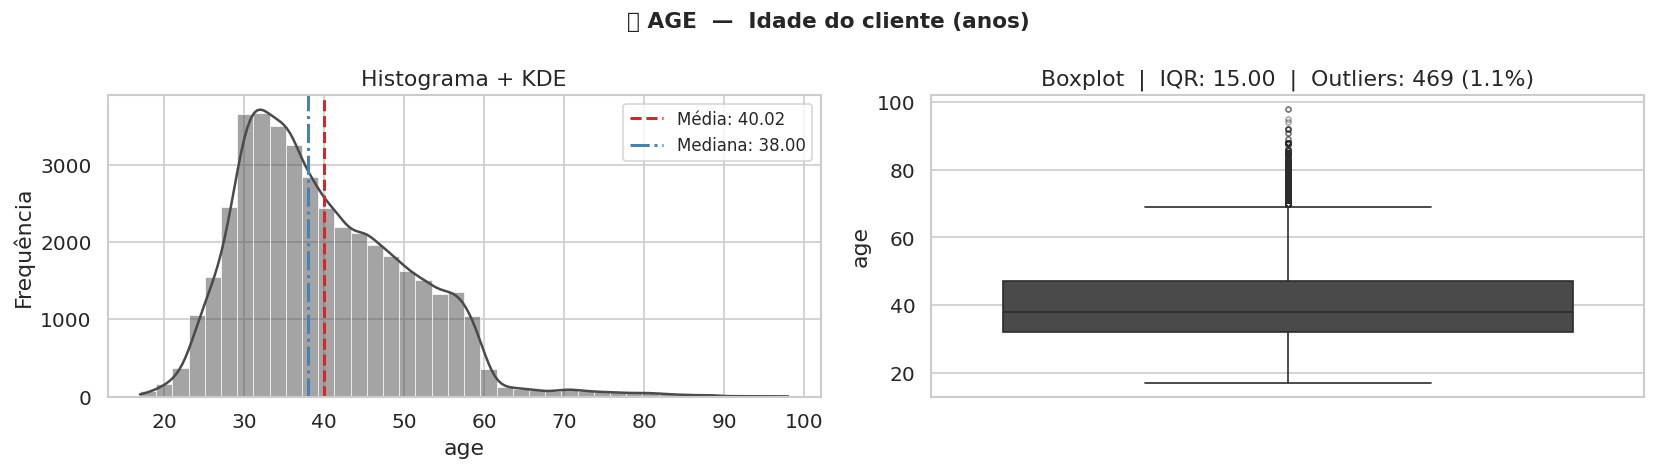

   Assimetria (skew): 0.785  → cauda à direita  |  Outliers: 469



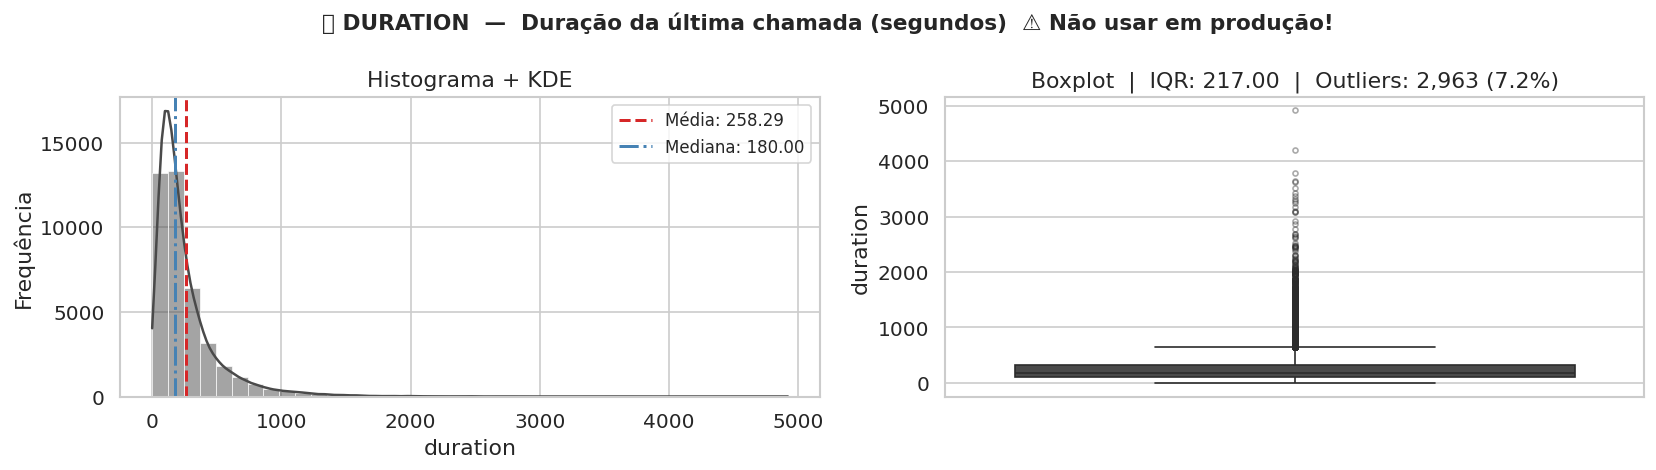

   Assimetria (skew): 3.263  → cauda à direita  |  Outliers: 2,963



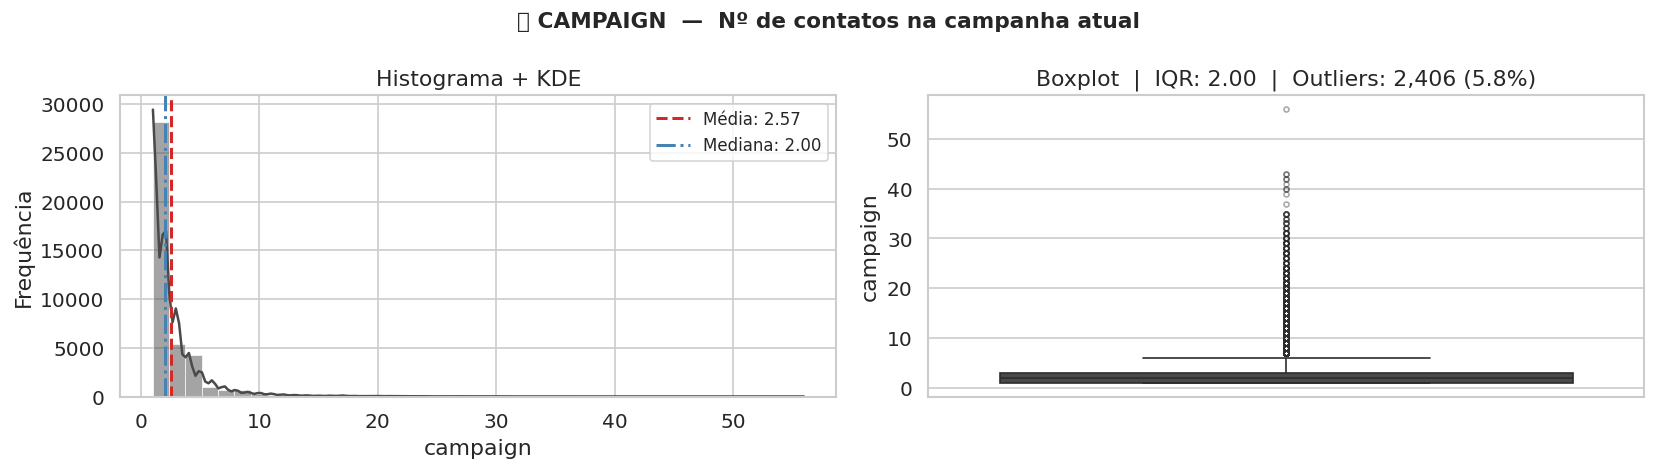

   Assimetria (skew): 4.763  → cauda à direita  |  Outliers: 2,406



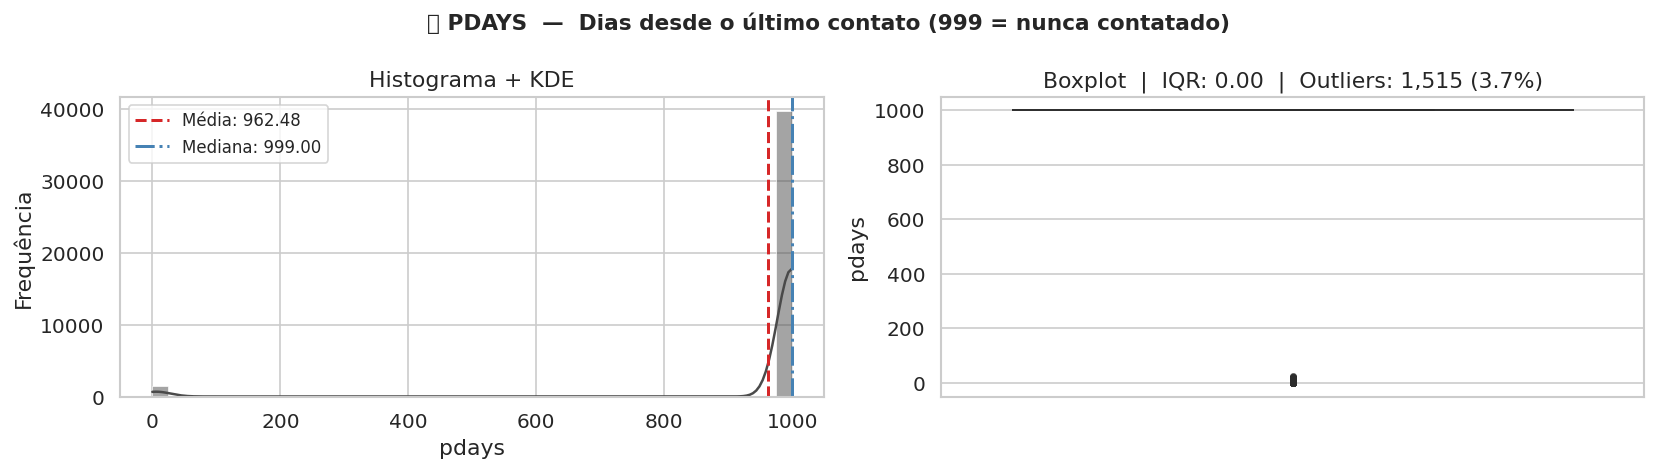

   Assimetria (skew): -4.922  → cauda à esquerda  |  Outliers: 1,515



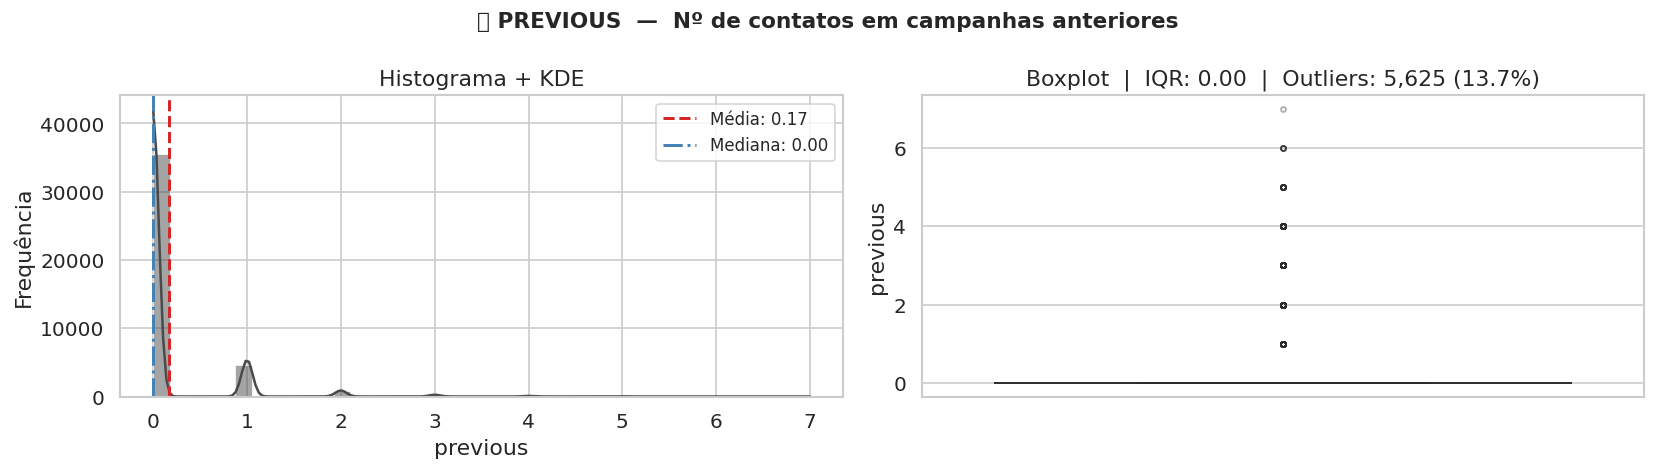

   Assimetria (skew): 3.832  → cauda à direita  |  Outliers: 5,625



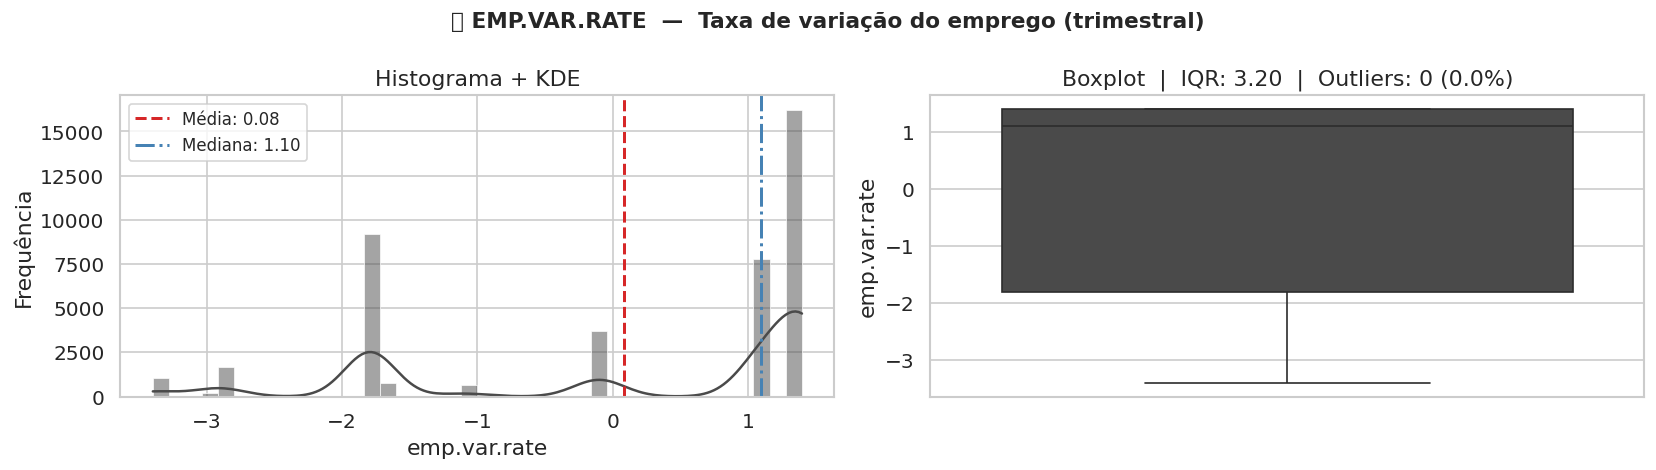

   Assimetria (skew): -0.724  → cauda à esquerda  |  Outliers: 0



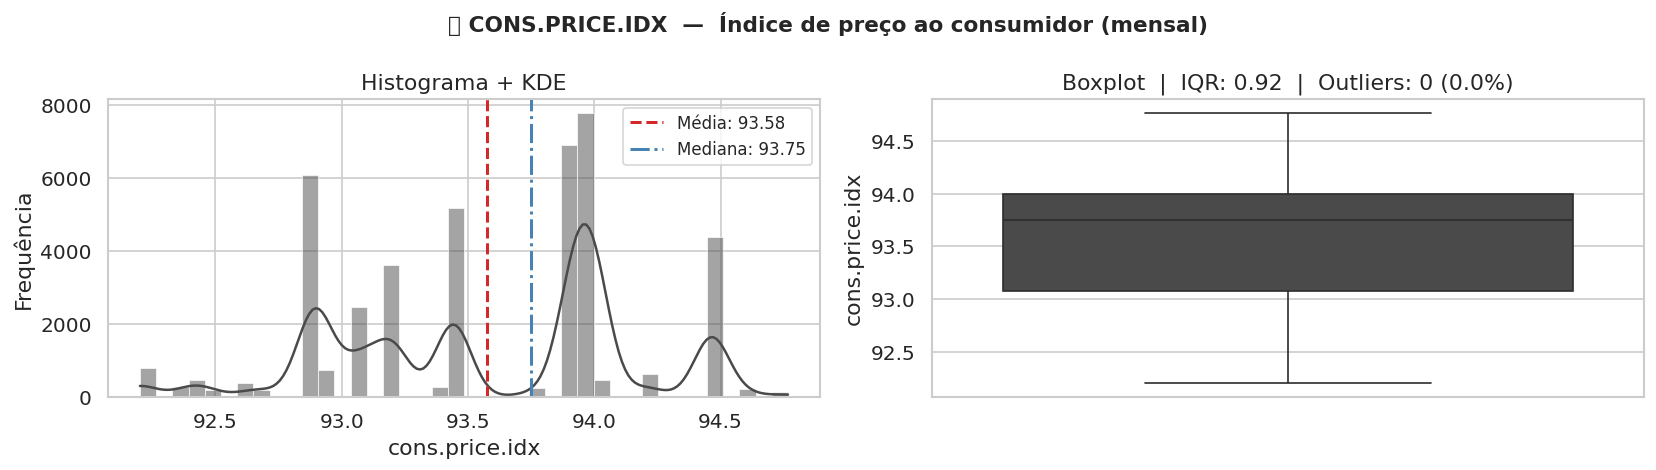

   Assimetria (skew): -0.231  → aproximadamente simétrica  |  Outliers: 0



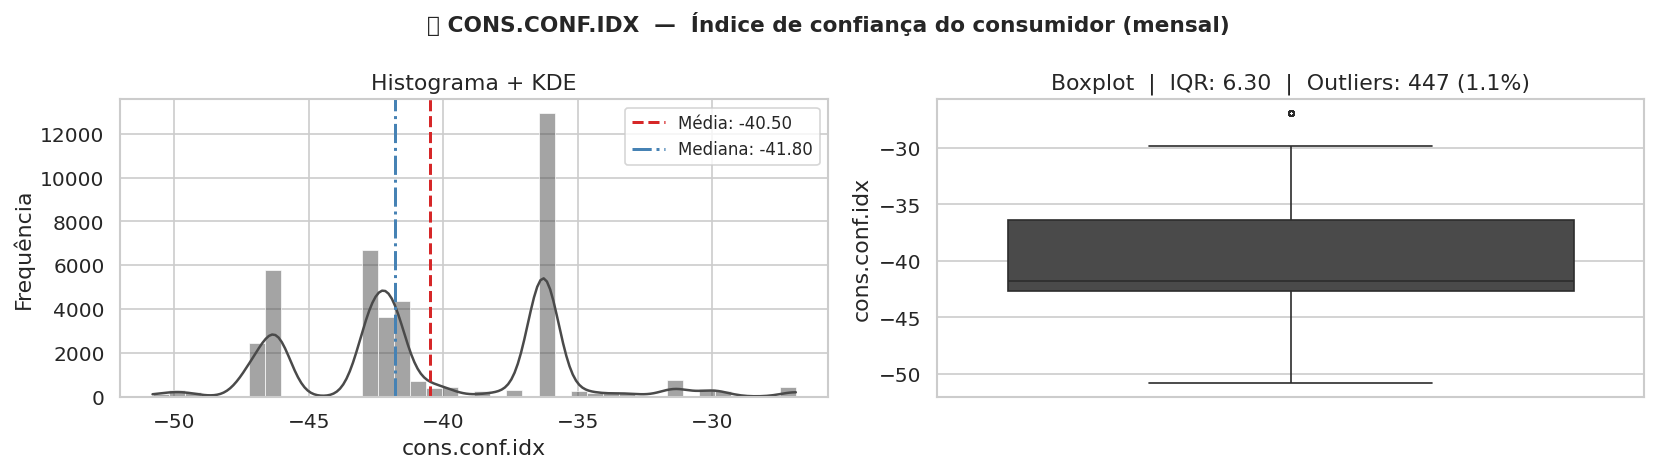

   Assimetria (skew): 0.303  → aproximadamente simétrica  |  Outliers: 447



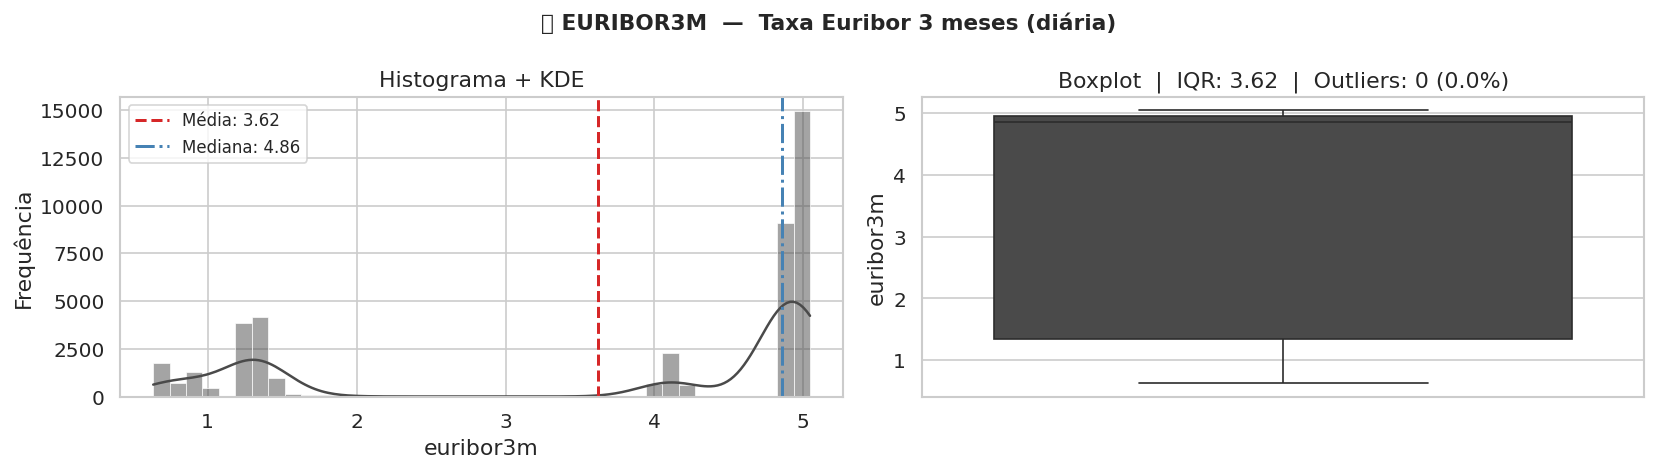

   Assimetria (skew): -0.709  → cauda à esquerda  |  Outliers: 0



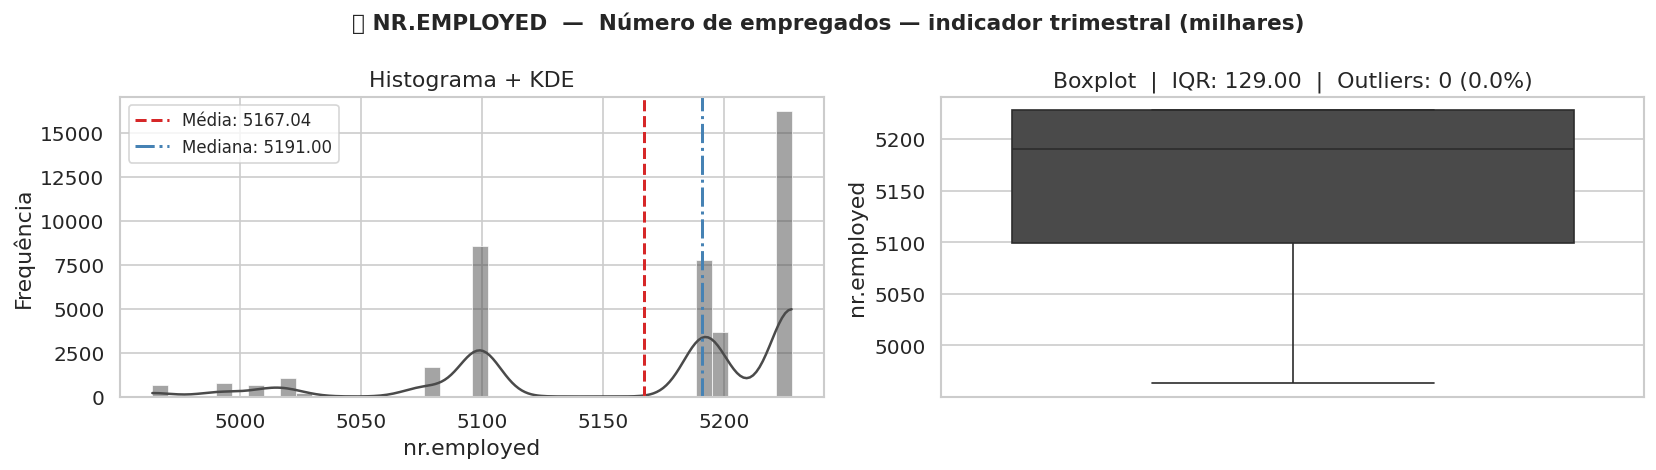

   Assimetria (skew): -1.044  → cauda à esquerda  |  Outliers: 0



In [7]:
# ============================================================
# CÉLULA 6 — Loop de análise univariada numérica
# ============================================================

# Seleção automática das colunas numéricas (excluindo o target)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Variáveis numéricas: {num_cols}\n')

# Dicionário com contexto de negócio para cada variável
descricoes = {
    'age'           : 'Idade do cliente (anos)',
    'duration'      : 'Duração da última chamada (segundos)  ⚠️ Não usar em produção!',
    'campaign'      : 'Nº de contatos na campanha atual',
    'pdays'         : 'Dias desde o último contato (999 = nunca contatado)',
    'previous'      : 'Nº de contatos em campanhas anteriores',
    'emp.var.rate'  : 'Taxa de variação do emprego (trimestral)',
    'cons.price.idx': 'Índice de preço ao consumidor (mensal)',
    'cons.conf.idx' : 'Índice de confiança do consumidor (mensal)',
    'euribor3m'     : 'Taxa Euribor 3 meses (diária)',
    'nr.employed'   : 'Número de empregados — indicador trimestral (milhares)',
}

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    titulo = descricoes.get(col, col)
    fig.suptitle(f'📊 {col.upper()}  —  {titulo}', fontsize=13, fontweight='bold')

    # --- Histograma ---
    ax1 = axes[0]
    # KDE + histograma para visualizar a densidade real
    sns.histplot(df[col], ax=ax1, bins=40, color=COR_NO,
                 kde=True, edgecolor='white', linewidth=0.4)
    ax1.axvline(df[col].mean(),   color=COR_YES,    linestyle='--',
                linewidth=1.8, label=f'Média: {df[col].mean():.2f}')
    ax1.axvline(df[col].median(), color='steelblue', linestyle='-.',
                linewidth=1.8, label=f'Mediana: {df[col].median():.2f}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequência')
    ax1.set_title('Histograma + KDE')
    ax1.legend(fontsize=10)

    # --- Boxplot ---
    ax2 = axes[1]
    sns.boxplot(y=df[col], ax=ax2, color=COR_NO,
                flierprops=dict(marker='o', color=COR_YES, alpha=0.4, markersize=3))
    # Estatísticas anotadas
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    ax2.set_title(f'Boxplot  |  IQR: {iqr:.2f}  |  Outliers: {n_out:,} ({n_out/len(df)*100:.1f}%)')
    ax2.set_ylabel(col)

    plt.tight_layout()
    plt.savefig(f'fig_num_{col}.png', dpi=120)
    plt.show()

    # Mini-resumo estatístico
    skew = df[col].skew()
    sinal = '→ cauda à direita' if skew > 0.5 else ('→ cauda à esquerda' if skew < -0.5 else '→ aproximadamente simétrica')
    print(f'   Assimetria (skew): {skew:.3f}  {sinal}  |  Outliers: {n_out:,}\n')

---
## 5. 📋 Análise Univariada — Variáveis Categóricas

Para variáveis categóricas, gráficos de barra (countplots) mostram a **frequência de cada categoria**.  
Ordenamos da mais frequente para a menos frequente para facilitar a leitura.

**Ponto de atenção:** Categorias com `'unknown'` indicam dados ausentes mascarados.  
Na etapa de pré-processamento, precisaremos decidir: imputar ou remover?

**Variáveis categóricas:**  
`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`

Variáveis categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']



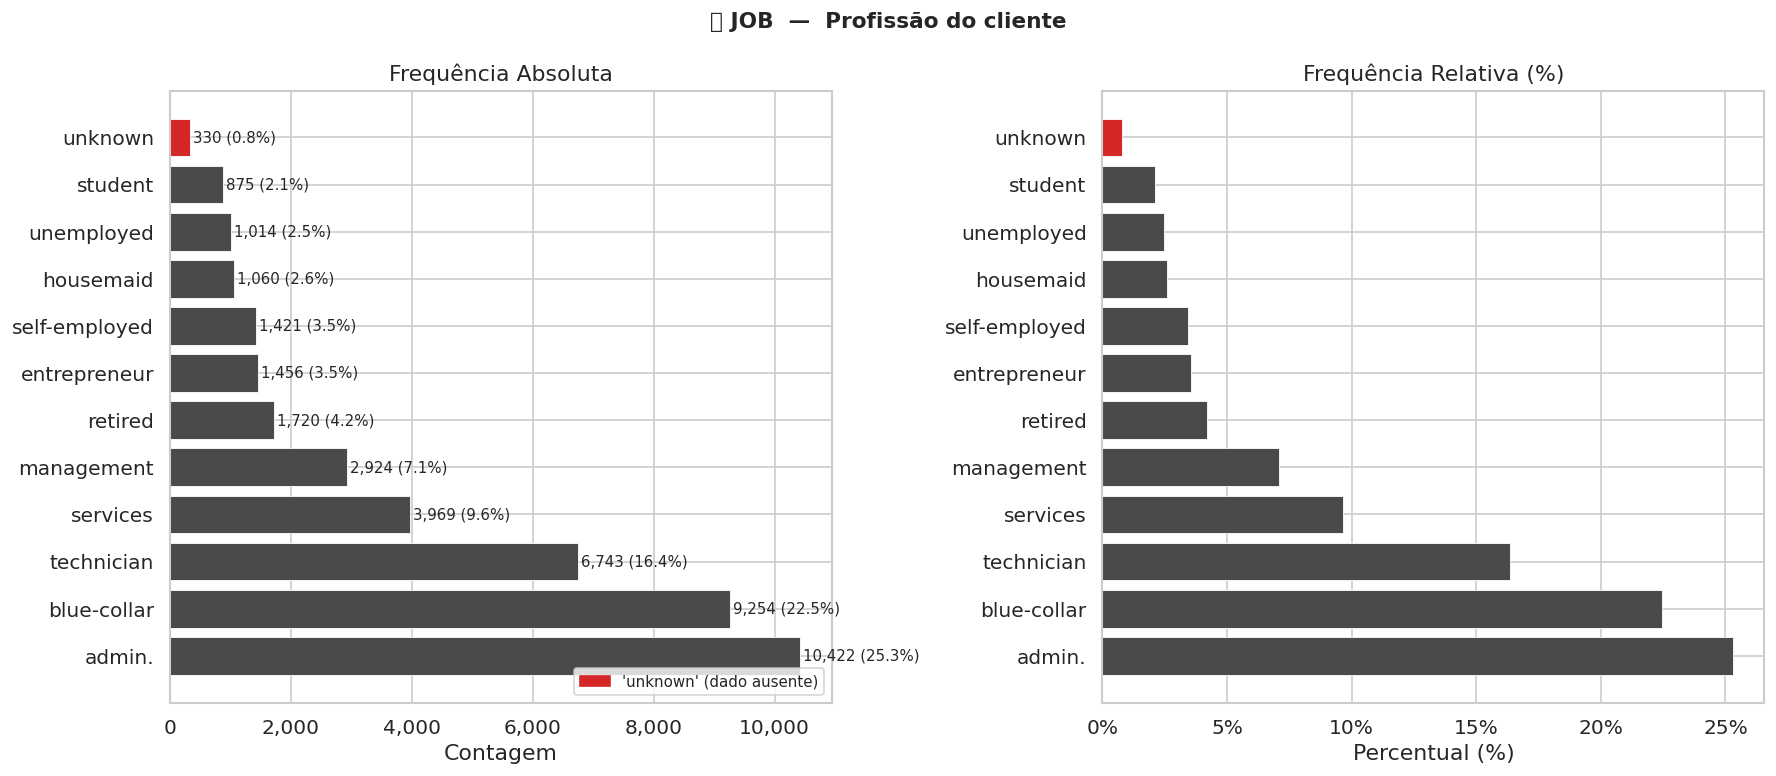

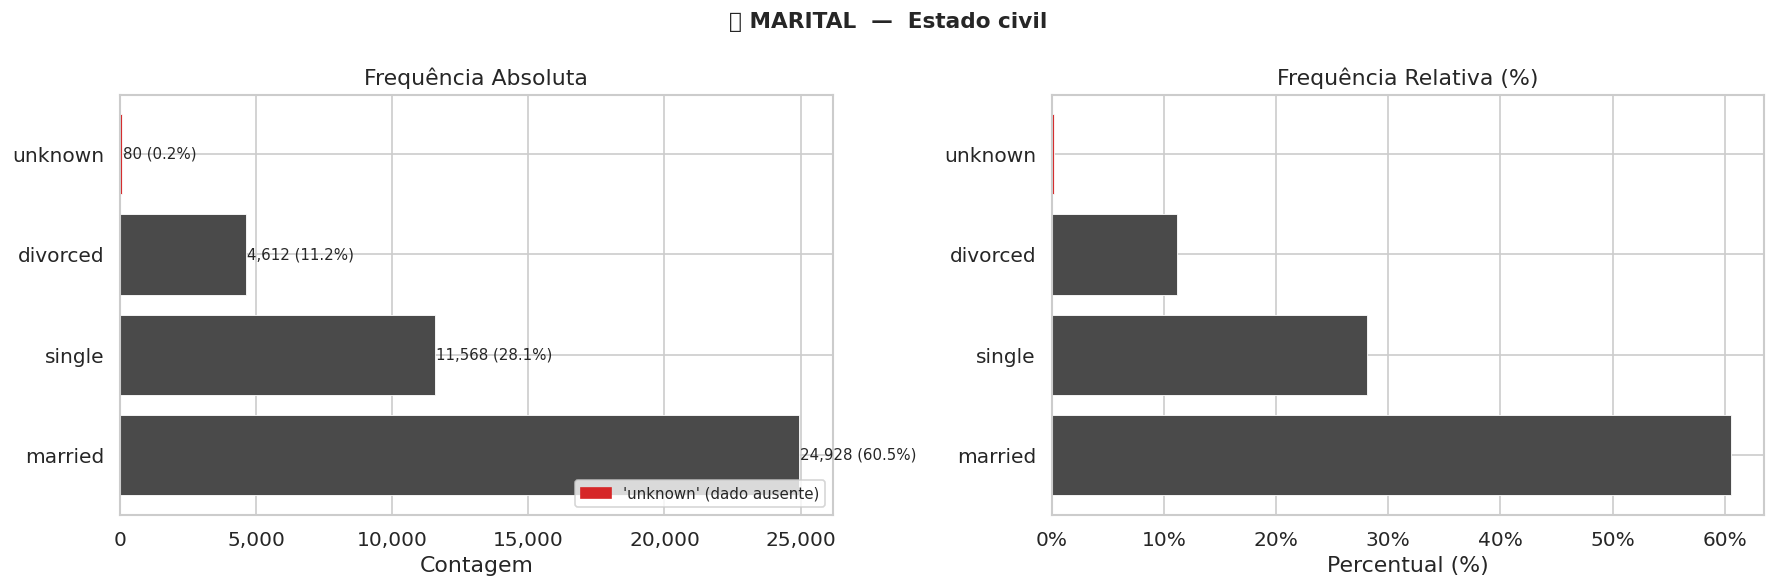

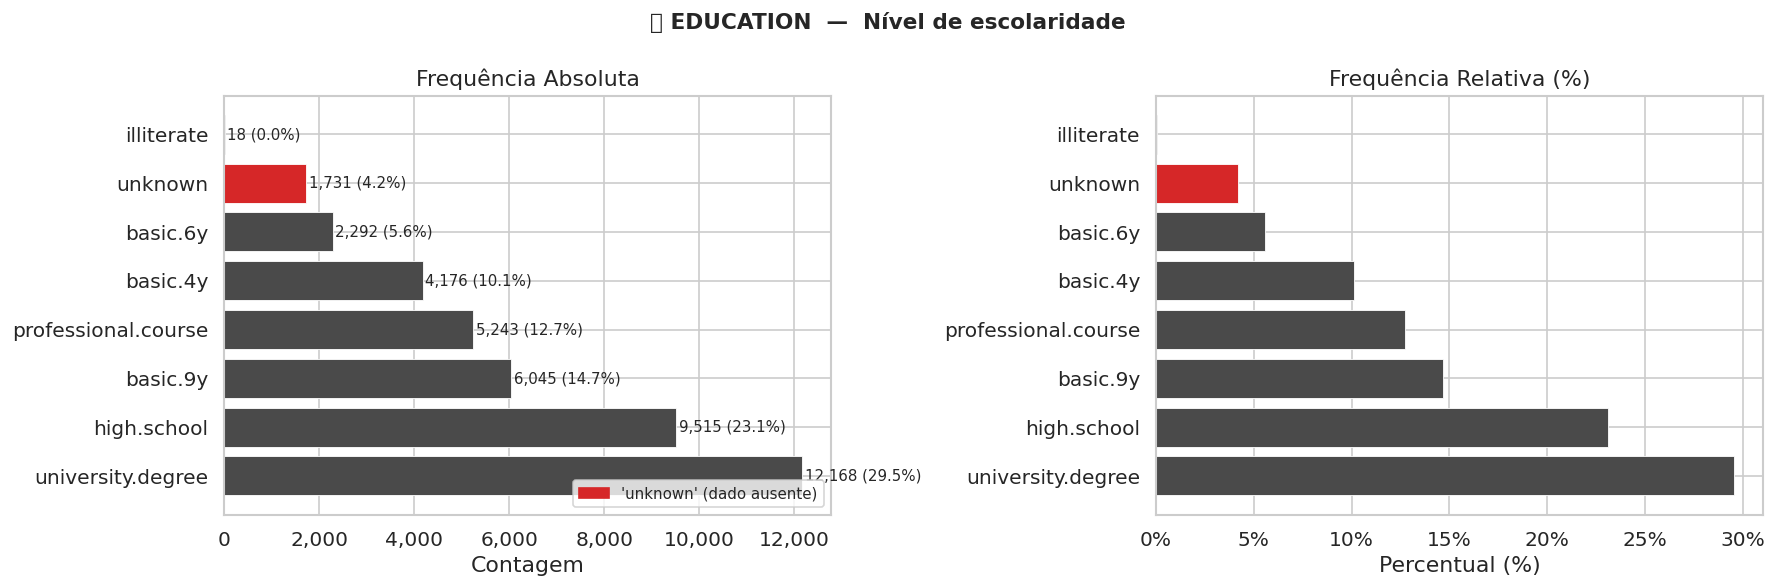

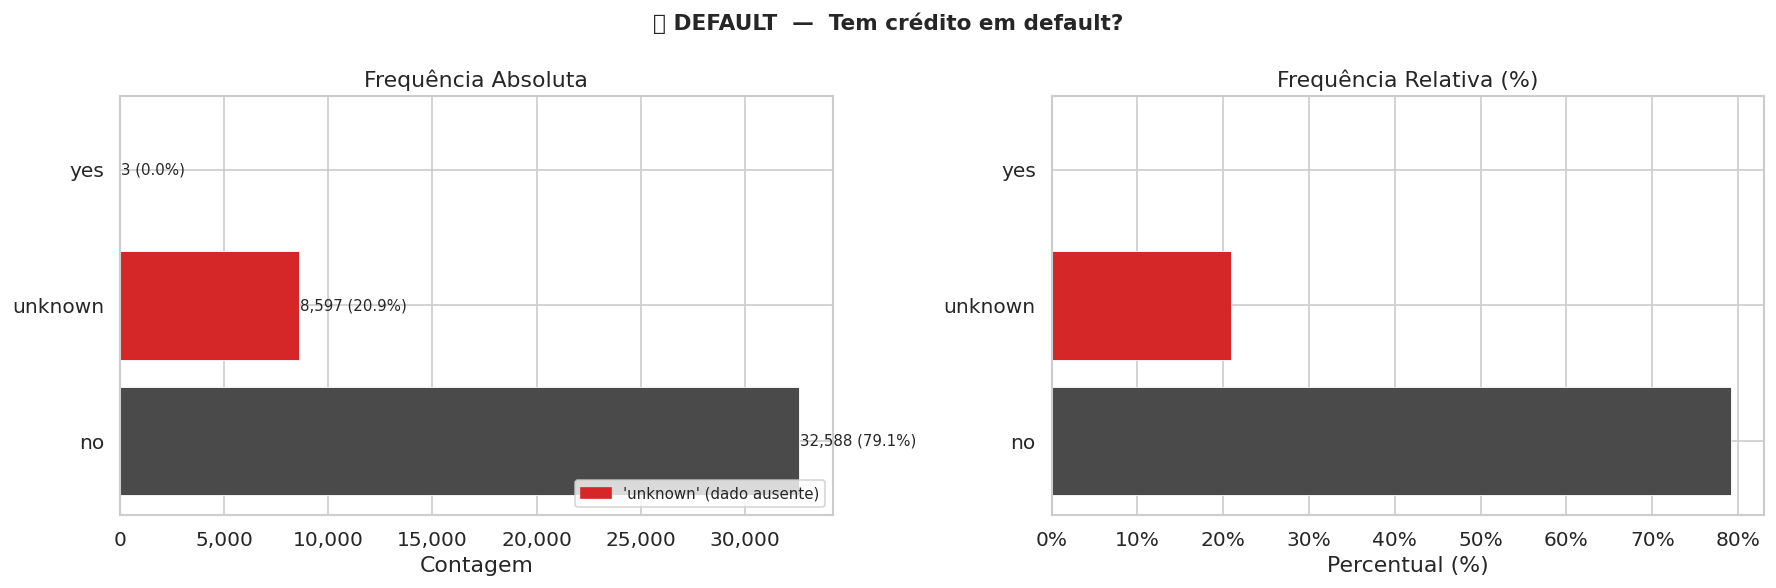

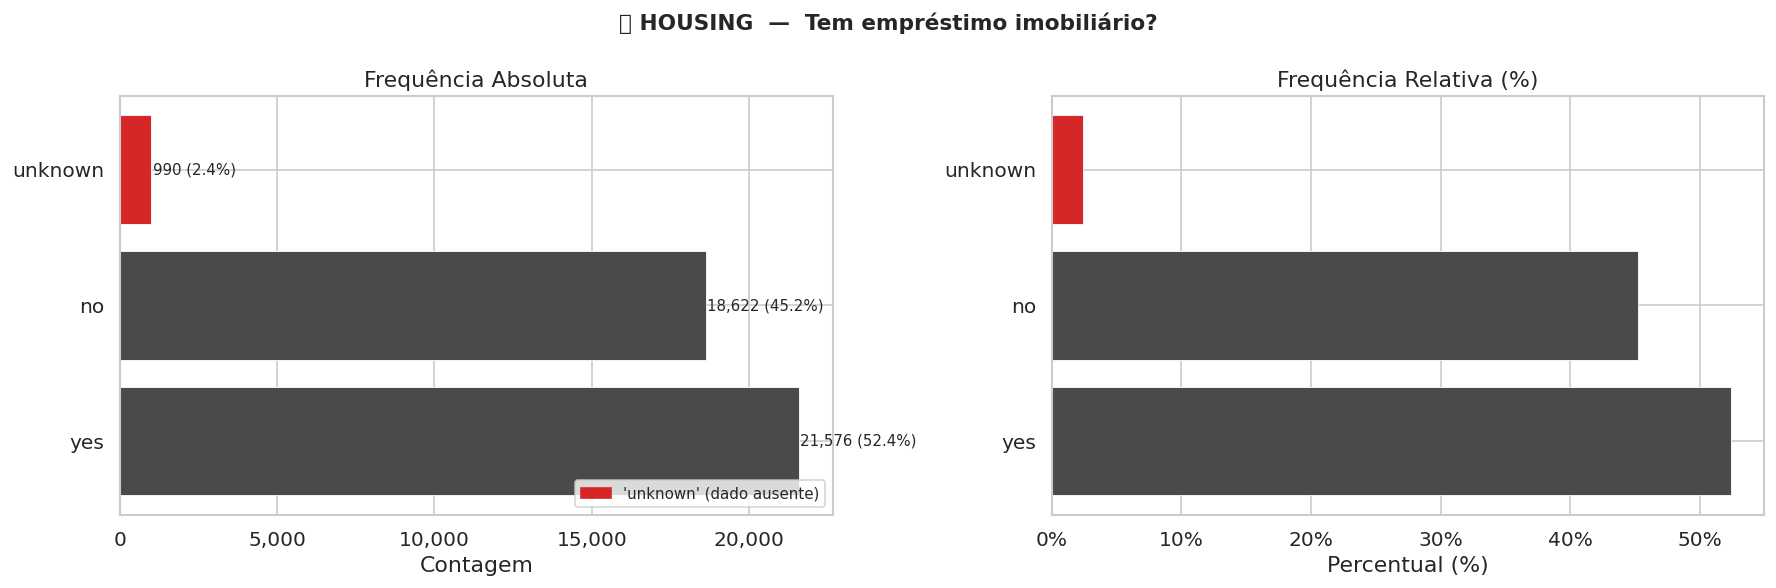

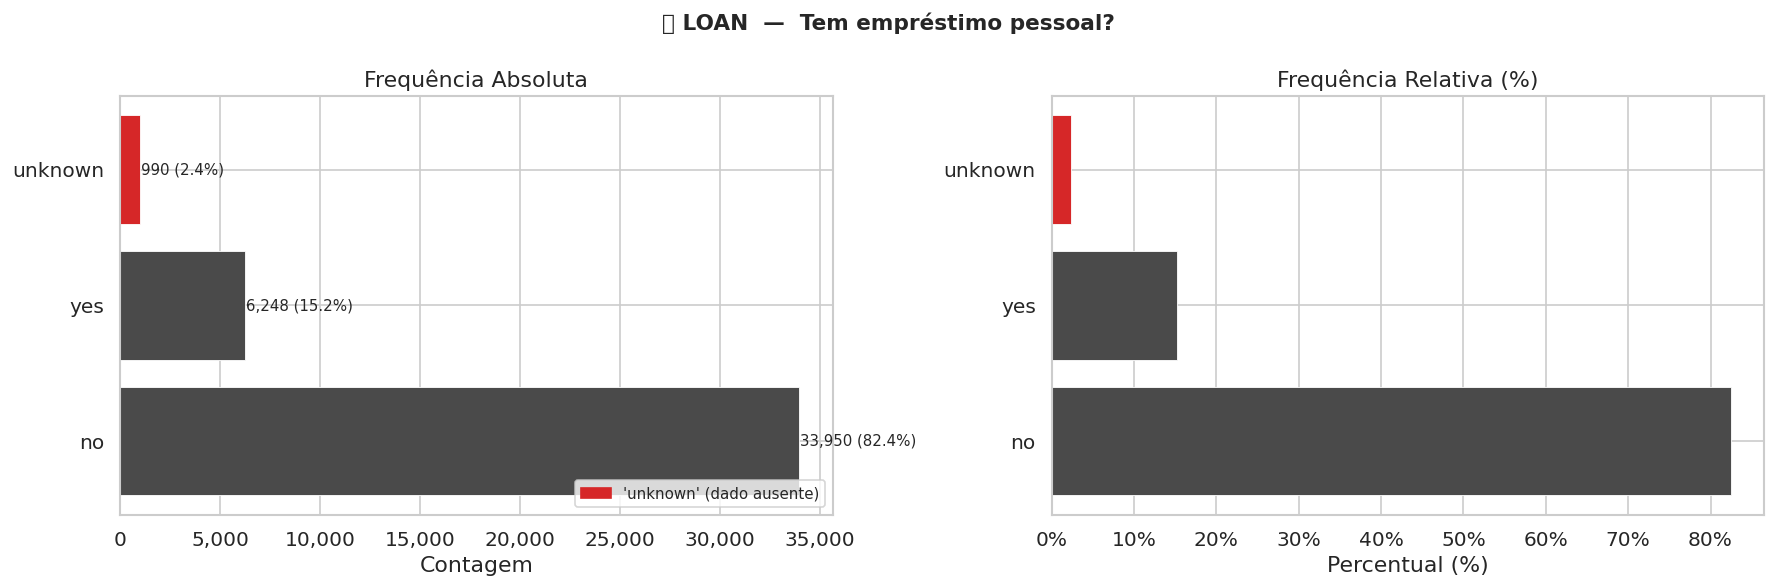

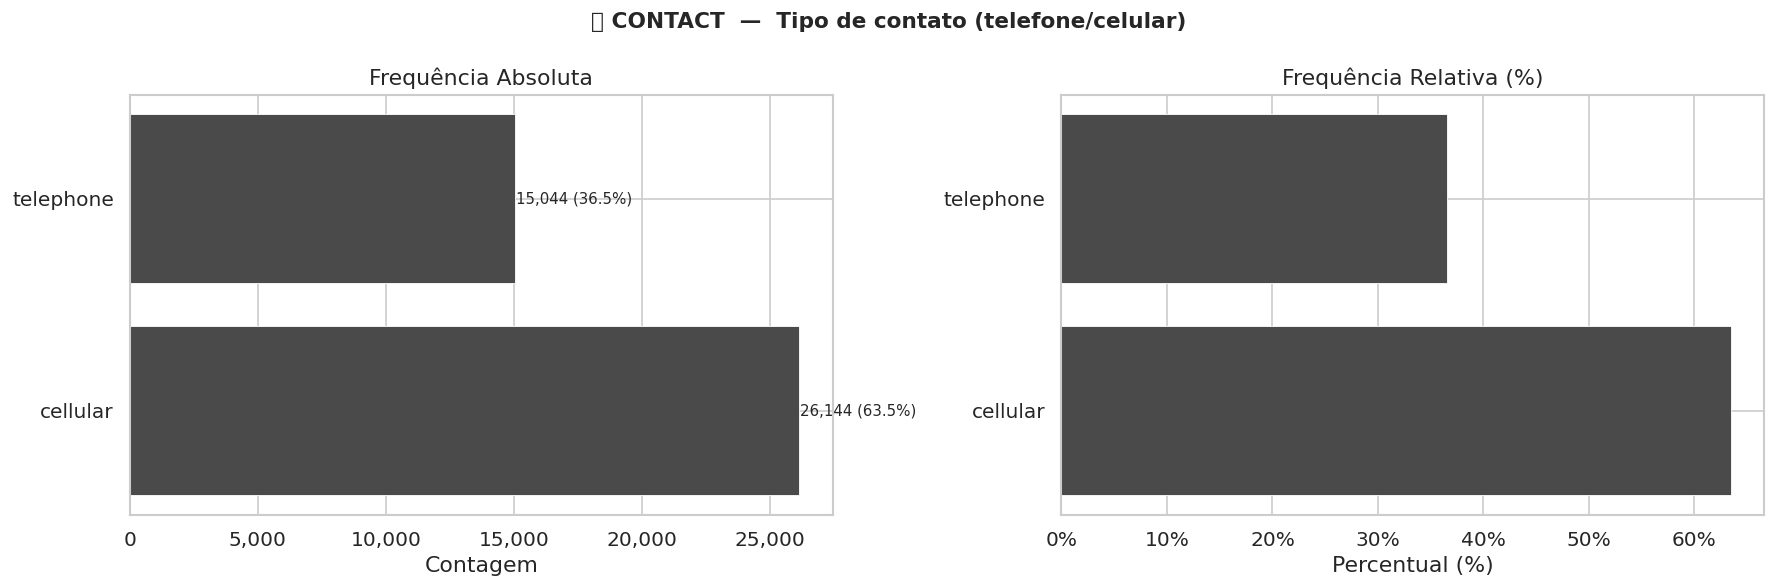

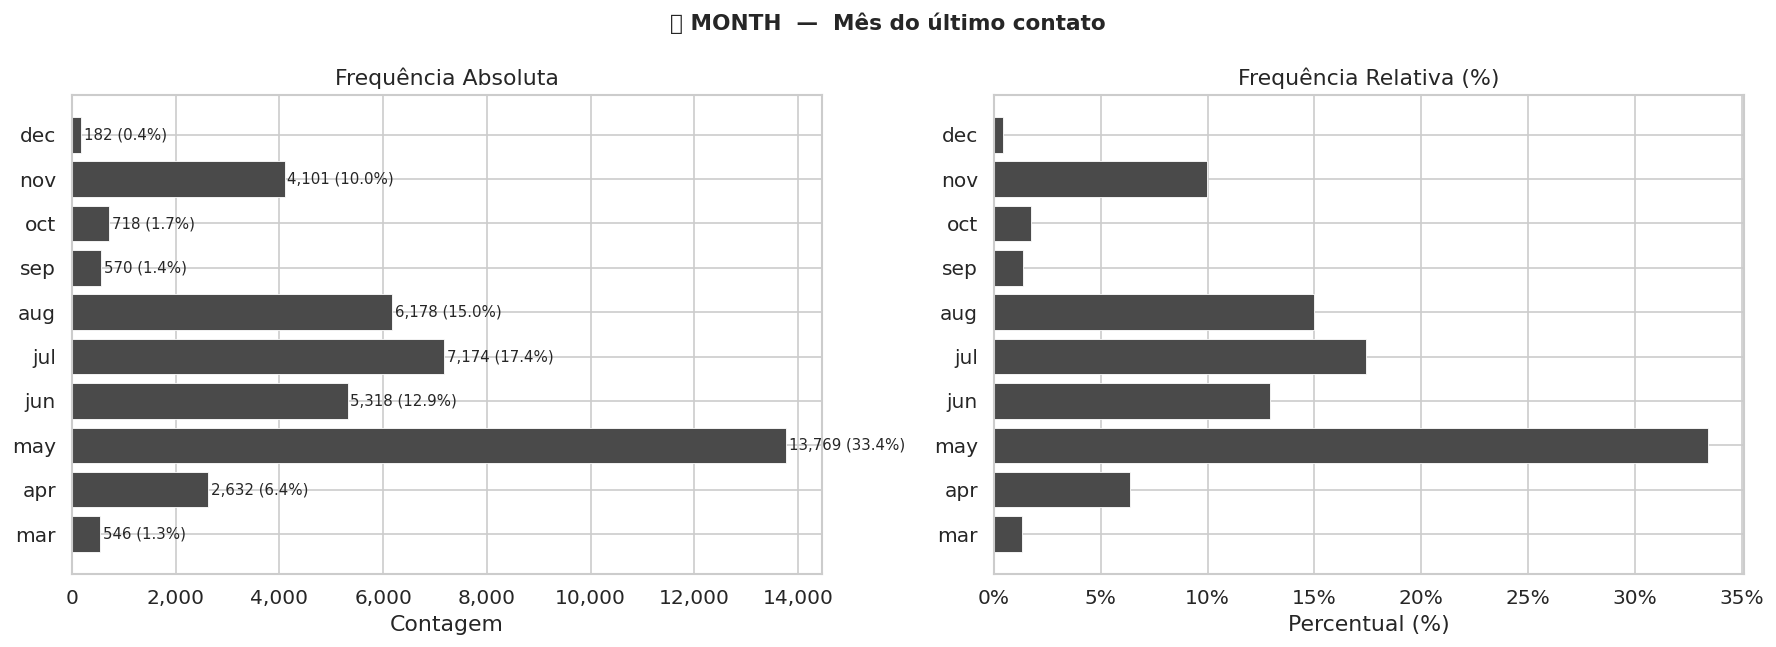

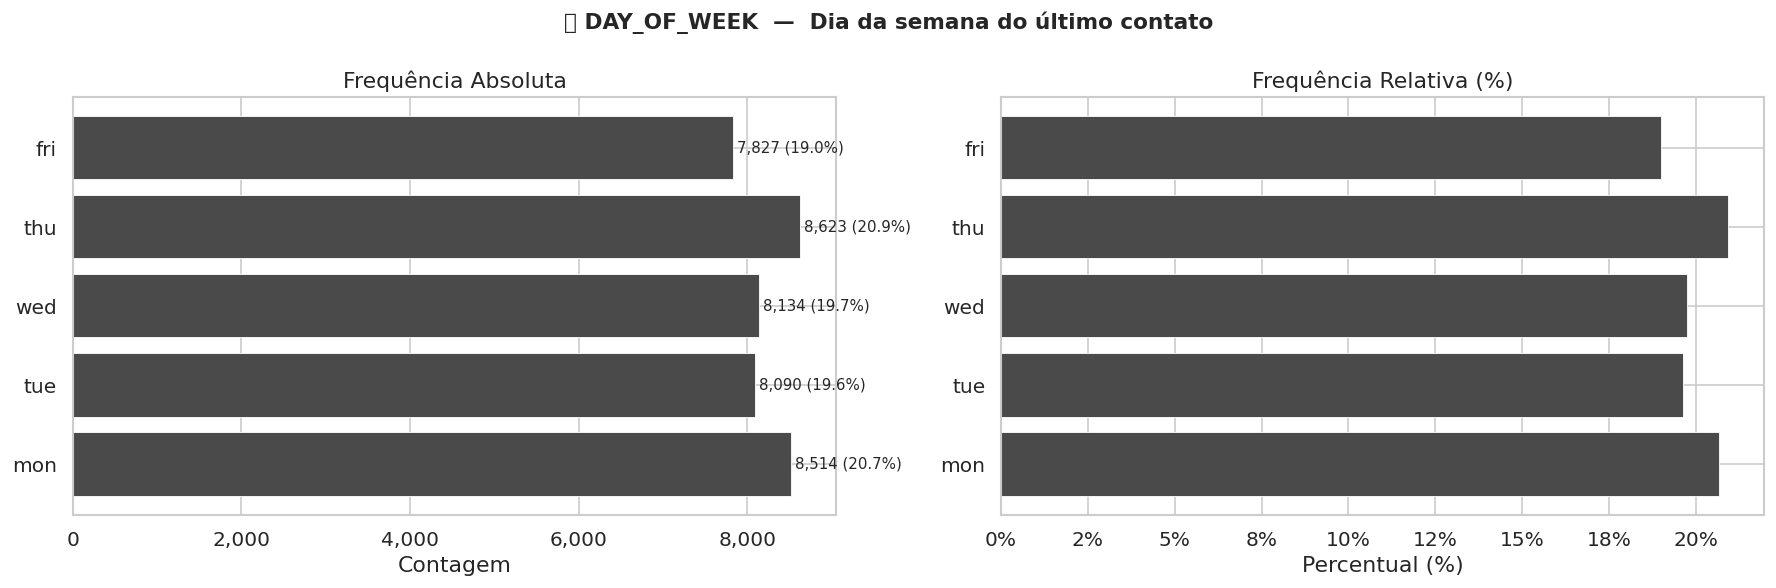

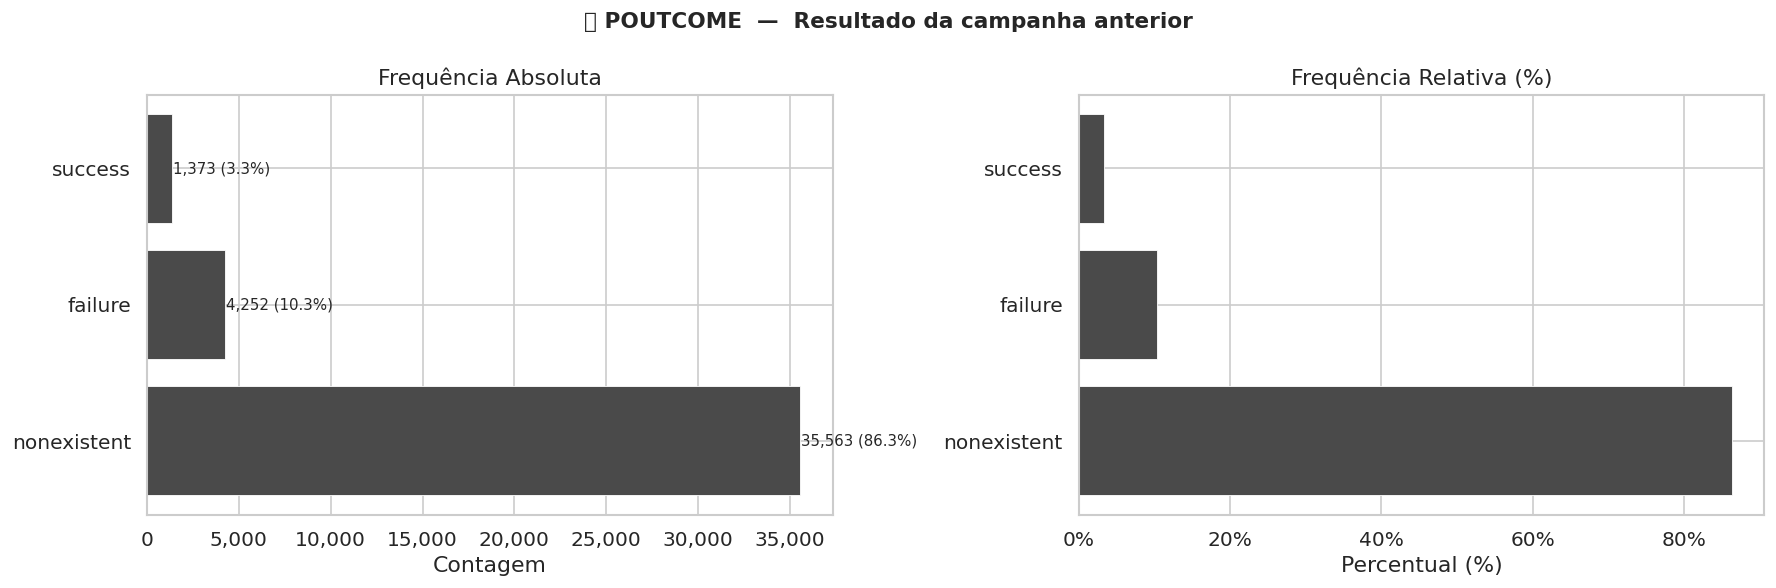

In [8]:
# ============================================================
# CÉLULA 7 — Loop de análise univariada categórica
# ============================================================

# Colunas categóricas (excluindo o target 'y')
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'y']
print(f'Variáveis categóricas: {cat_cols}\n')

# Contexto de negócio
descricoes_cat = {
    'job'        : 'Profissão do cliente',
    'marital'    : 'Estado civil',
    'education'  : 'Nível de escolaridade',
    'default'    : 'Tem crédito em default?',
    'housing'    : 'Tem empréstimo imobiliário?',
    'loan'       : 'Tem empréstimo pessoal?',
    'contact'    : 'Tipo de contato (telefone/celular)',
    'month'      : 'Mês do último contato',
    'day_of_week': 'Dia da semana do último contato',
    'poutcome'   : 'Resultado da campanha anterior',
}

# Ordem correta para mês e dia
ordem_mes = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
ordem_dia = ['mon','tue','wed','thu','fri']

for col in cat_cols:
    # Definir ordem
    if col == 'month':
        ordem = [m for m in ordem_mes if m in df[col].unique()]
    elif col == 'day_of_week':
        ordem = [d for d in ordem_dia if d in df[col].unique()]
    else:
        ordem = df[col].value_counts().index.tolist()

    n_cats = len(ordem)
    altura  = max(5, n_cats * 0.55)

    fig, axes = plt.subplots(1, 2, figsize=(15, altura))
    titulo = descricoes_cat.get(col, col)
    fig.suptitle(f'📋 {col.upper()}  —  {titulo}', fontsize=13, fontweight='bold')

    # --- Countplot horizontal ---
    ax1 = axes[0]
    vc = df[col].value_counts()
    # Colorir 'unknown' em vermelho
    cores_barras = [COR_YES if cat == 'unknown' else COR_NO for cat in ordem]
    bars = ax1.barh([str(c) for c in ordem],
                    [vc.get(c, 0) for c in ordem],
                    color=cores_barras, edgecolor='white', linewidth=0.5)
    ax1.set_xlabel('Contagem')
    ax1.set_title('Frequência Absoluta')
    ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    # Rótulos
    for bar, cat in zip(bars, ordem):
        val = vc.get(cat, 0)
        pct = val / len(df) * 100
        ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)

    # --- Frequência relativa ---
    ax2 = axes[1]
    pct_vals = [(vc.get(c, 0) / len(df) * 100) for c in ordem]
    ax2.barh([str(c) for c in ordem], pct_vals,
             color=cores_barras, edgecolor='white', linewidth=0.5)
    ax2.set_xlabel('Percentual (%)')
    ax2.set_title('Frequência Relativa (%)')
    ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    if 'unknown' in df[col].values:
        from matplotlib.patches import Patch
        ax1.legend(handles=[Patch(color=COR_YES, label="'unknown' (dado ausente)")],
                   loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'fig_cat_{col}.png', dpi=120)
    plt.show()
    print()

---
## 6. 🔍 Análise Bivariada — Features × Target (`y`)

A análise bivariada é onde extraímos os **insights de negócio mais valiosos**: quais características
distinguem clientes que assinam dos que não assinam.

### 6.1 Variáveis Numéricas × Target
Boxplots lado a lado (`hue=y`) permitem comparar visualmente a distribuição de cada variável
numérica entre clientes que converteram (`yes`) e os que não converteram (`no`).

> **O que procurar:** Se as caixas estiverem em regiões diferentes → a variável tem poder discriminativo!

In [ ]:
# ============================================================
# CÉLULA 8 — Análise bivariada: numéricas × target
# ============================================================

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 28))
axes = axes.flatten()
fig.suptitle('Variáveis Numéricas × Variável Alvo (y)\n'
             'Vermelho = assinou | Cinza = não assinou',
             fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(
        data=df, x='y', y=col, ax=ax,
        order=['no', 'yes'],
        palette={'no': COR_NO, 'yes': COR_YES},
        flierprops=dict(marker='o', alpha=0.2, markersize=2)
    )
    # Adiciona a mediana como anotação textual
    for j, classe in enumerate(['no', 'yes']):
        med = df[df['y'] == classe][col].median()
        ax.text(j, med, f' {med:.1f}', va='center', fontsize=9,
                color='white', fontweight='bold')

    titulo_biv = descricoes.get(col, col)
    ax.set_title(f'{col}  —  {titulo_biv}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Assinou depósito? (y)')
    ax.set_ylabel(col)

# Ocultar eixos vazios se houver
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('fig_biv_numericas.png', dpi=120)
plt.show()
print('💡 Observação: duration e euribor3m apresentam as maiores diferenças entre as classes!')

### 6.2 Variáveis Categóricas × Target — Taxa de Conversão

Para cada variável categórica, calculamos a **taxa de conversão** (% de `yes`) por categoria.  
Isso responde diretamente: *"Clientes de qual profissão/escolaridade/mês convertem mais?"*

> **Insight esperado:** Aposentados (retired), estudantes e contatos por celular tendem a ter  
> taxas de conversão superiores à média geral.

In [ ]:
# ============================================================
# CÉLULA 9 — Taxa de conversão por variável categórica
# ============================================================

# Cria coluna numérica temporária do target (0/1)
df['y_num'] = (df['y'] == 'yes').astype(int)
taxa_global = df['y_num'].mean() * 100

print(f'Taxa de conversão global: {taxa_global:.2f}%\n')

for col in cat_cols:
    # Calcular contagem e taxa de conversão por categoria
    resumo = df.groupby(col).agg(
        total    = ('y_num', 'count'),
        sim      = ('y_num', 'sum')
    ).reset_index()
    resumo['taxa_pct'] = (resumo['sim'] / resumo['total'] * 100).round(2)
    resumo = resumo.sort_values('taxa_pct', ascending=True)

    n_cats = len(resumo)
    altura = max(5, n_cats * 0.6)

    fig, axes = plt.subplots(1, 2, figsize=(16, altura))
    titulo = descricoes_cat.get(col, col)
    fig.suptitle(f'🎯 {col.upper()} × Taxa de Conversão  —  {titulo}',
                 fontsize=13, fontweight='bold')

    # --- Gráfico 1: Barras empilhadas (no vs yes) ---
    ax1 = axes[0]
    n_no  = resumo['total'] - resumo['sim']
    n_yes = resumo['sim']
    bars_no  = ax1.barh(resumo[col], n_no,  color=COR_NO,  label='Não (no)',  edgecolor='white', lw=0.4)
    bars_yes = ax1.barh(resumo[col], n_yes, left=n_no, color=COR_YES, label='Sim (yes)', edgecolor='white', lw=0.4)
    ax1.set_xlabel('Quantidade de Clientes')
    ax1.set_title('Volume por Categoria (empilhado)')
    ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax1.legend(loc='lower right')

    # --- Gráfico 2: Taxa de conversão (%) ---
    ax2 = axes[1]
    cores = [COR_YES if t >= taxa_global else COR_NO for t in resumo['taxa_pct']]
    bars_tx = ax2.barh(resumo[col], resumo['taxa_pct'], color=cores, edgecolor='white', lw=0.4)
    # Linha da taxa global
    ax2.axvline(taxa_global, color='steelblue', linestyle='--', linewidth=1.5,
                label=f'Média global: {taxa_global:.1f}%')
    ax2.set_xlabel('Taxa de Conversão (%)')
    ax2.set_title('Taxa de Conversão por Categoria')
    ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax2.legend(fontsize=10)
    # Rótulos de percentual
    for bar, val in zip(bars_tx, resumo['taxa_pct']):
        ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'fig_biv_{col}.png', dpi=120)
    plt.show()

    # Destaque das categorias acima da média
    acima = resumo[resumo['taxa_pct'] >= taxa_global].sort_values('taxa_pct', ascending=False)
    print(f'  → Categorias ACIMA da média global ({taxa_global:.1f}%):')
    for _, row in acima.iterrows():
        print(f'     {row[col]:>20} : {row["taxa_pct"]:.1f}%  ({row["total"]:,} clientes)')
    print()

---
## 7. 🔥 Matriz de Correlação

A correlação de Pearson mede a **intensidade e direção da associação linear** entre duas variáveis numéricas.  
Varia de **-1** (correlação negativa perfeita) a **+1** (correlação positiva perfeita).

**Na prática para ML:**
- Variáveis altamente correlacionadas entre si (multicolinearidade) podem prejudicar modelos como Regressão Logística
- Variáveis correlacionadas com o **target** (y_num) são candidatas a features importantes

> **⚠️ Atenção:** `duration` é fortemente correlacionada com `y`, mas **não deve ser usada como feature  
> em modelos de produção** — a duração só é conhecida APÓS a chamada acontecer!

In [ ]:
# ============================================================
# CÉLULA 10 — Matriz de correlação com heatmap
# ============================================================

# Seleciona numéricas + target numérico
cols_corr = num_cols + ['y_num']
corr_matrix = df[cols_corr].corr()

# Máscara para triângulo superior (evita redundância)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Matriz de Correlação de Pearson\n'
             'Variáveis Numéricas + Target (y_num)',
             fontsize=14, fontweight='bold')

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',           # vermelho negativo, azul positivo
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlação de Pearson', 'shrink': 0.8},
    annot_kws={'size': 9},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('fig_correlacao_heatmap.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# CÉLULA 11 — Correlação ordenada com o TARGET
# ============================================================

corr_target = corr_matrix['y_num'].drop('y_num').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COR_YES if v > 0 else 'steelblue' for v in corr_target]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white', lw=0.5)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Correlação de Pearson com y (assinou depósito)')
ax.set_title('Correlação das Features com o Target (y_num)\n'
             'Vermelho = correlação positiva | Azul = correlação negativa',
             fontweight='bold')

for bar, val in zip(bars, corr_target.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_correlacao_target.png', dpi=150)
plt.show()

print('📊 Top features por correlação com y (valor absoluto):')
print(corr_target.apply(lambda x: f'{x:+.4f}').to_string())

---
## 8. 🔎 Análise Extra — Indicadores Econômicos e Sazonalidade

Esta seção explora dois padrões críticos que o dataset enriquecido permite identificar:
1. **Contexto macroeconômico:** Taxas de juros e emprego influenciam a decisão de investir em depósitos?
2. **Sazonalidade:** Existe um mês do ano com maior propensão de conversão?

In [ ]:
# ============================================================
# CÉLULA 12 — Sazonalidade: taxa de conversão por mês
# ============================================================

ordem_mes_filtrada = [m for m in ordem_mes if m in df['month'].unique()]

taxa_mes = df.groupby('month')['y_num'].agg(['mean','count']).reset_index()
taxa_mes['mean'] *= 100
# Ordena por calendário
taxa_mes['month_ord'] = taxa_mes['month'].apply(
    lambda m: ordem_mes_filtrada.index(m) if m in ordem_mes_filtrada else 99
)
taxa_mes = taxa_mes.sort_values('month_ord')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

cores_mes = [COR_YES if t >= taxa_global else COR_NO for t in taxa_mes['mean']]
bars = ax1.bar(taxa_mes['month'], taxa_mes['mean'], color=cores_mes,
               edgecolor='white', linewidth=0.5, width=0.6, label='Taxa de Conversão (%)')
ax2.plot(taxa_mes['month'], taxa_mes['count'], 'o--', color='steelblue',
         linewidth=2, markersize=8, label='Volume de Contatos')

ax1.axhline(taxa_global, color='darkred', linestyle=':', linewidth=1.5,
            label=f'Média global: {taxa_global:.1f}%')

for bar, val in zip(bars, taxa_mes['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('Mês do Último Contato')
ax1.set_ylabel('Taxa de Conversão (%)', color='black')
ax2.set_ylabel('Volume de Contatos', color='steelblue')
ax1.set_title('Sazonalidade: Taxa de Conversão e Volume por Mês',
              fontweight='bold', fontsize=13)

# Legendas combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('fig_sazonalidade_mes.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# CÉLULA 13 — Euribor vs. Taxa de Conversão (contexto macro)
# ============================================================

# Criamos bins do euribor para análise agregada
df['euribor_bin'] = pd.cut(df['euribor3m'], bins=5)

taxa_euribor = df.groupby('euribor_bin', observed=True)['y_num'].agg(['mean','count'])
taxa_euribor['mean'] *= 100

fig, ax = plt.subplots(figsize=(11, 5))

ax2 = ax.twinx()
cores_eur = [COR_YES if t >= taxa_global else COR_NO for t in taxa_euribor['mean']]
bars = ax.bar(range(len(taxa_euribor)), taxa_euribor['mean'],
              color=cores_eur, edgecolor='white', lw=0.5, width=0.6)
ax2.plot(range(len(taxa_euribor)), taxa_euribor['count'],
         'o--', color='steelblue', linewidth=2, markersize=8)

ax.axhline(taxa_global, color='darkred', linestyle=':', linewidth=1.5,
           label=f'Média global: {taxa_global:.1f}%')
ax.set_xticks(range(len(taxa_euribor)))
ax.set_xticklabels([str(i) for i in taxa_euribor.index], rotation=20, ha='right')
ax.set_xlabel('Faixa da Taxa Euribor 3 Meses')
ax.set_ylabel('Taxa de Conversão (%)')
ax2.set_ylabel('Volume de Clientes', color='steelblue')
ax.set_title('Taxa Euribor 3m × Taxa de Conversão\n'
             '(Juros altos → clientes mais propensos a poupar?)',
             fontweight='bold', fontsize=12)
ax.legend()

for bar, val in zip(bars, taxa_euribor['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_euribor_conversao.png', dpi=150)
plt.show()

# Remove coluna temporária
df.drop(columns=['euribor_bin'], inplace=True)

---
## 9. 📝 Síntese dos Insights — Resumo Executivo

Esta célula consolida os principais achados da EDA em um formato pronto para apresentação.

In [ ]:
# ============================================================
# CÉLULA 14 — Resumo executivo automatizado
# ============================================================

print('=' * 70)
print('  RESUMO EXECUTIVO — EDA Bank Marketing (UCI)'.center(70))
print('=' * 70)

print(f"""
📊 DATASET
   • {len(df):,} clientes | {df.shape[1]} variáveis (20 features + 1 target)
   • Período: Mai/2008 a Nov/2010
   • Separador: ponto e vírgula (;)

🎯 DESBALANCEAMENTO DA VARIÁVEL ALVO
   • Não assinaram (no) : {contagem_y['no']:,} ({pct_y['no']:.1f}%)
   • Assinaram (yes)    : {contagem_y['yes']:,} ({pct_y['yes']:.1f}%)
   • Ratio              : 1 sim para cada {ratio:.1f} nãos
   → Estratégia: usar class_weight='balanced' ou SMOTE na modelagem.

❓ DADOS AUSENTES (codificados como 'unknown')
""")

for col, row in unknown_df[unknown_df['qtd_unknown'] > 0].iterrows():
    print(f'   • {col:<15}: {row["qtd_unknown"]:>5,} ({row["pct_unknown"]}%)')

print(f"""
🔝 TOP FEATURES CORRELACIONADAS COM O TARGET (Pearson)
""")
top5 = corr_target.abs().nlargest(5)
for feat, val in top5.items():
    sinal = '+' if corr_target[feat] > 0 else '-'
    print(f'   {sinal} {feat:<20}: {corr_target[feat]:+.4f}')

print(f"""
💡 PRINCIPAIS INSIGHTS DE NEGÓCIO
   1. DURATION: chamadas mais longas → maior conversão. Porém, NUNCA usar
      como feature em produção (duração só é conhecida após a chamada).
   2. EURIBOR: quando os juros estão baixos, a conversão é menor. Clientes
      buscam depósitos a prazo mais quando os juros estão atrativos.
   3. POUTCOME: clientes com sucesso em campanhas anteriores têm a
      MAIOR taxa de conversão — recontactar quem já assinou antes é ouro.
   4. MONTH: março, setembro, outubro e dezembro têm taxas de conversão
      acima da média global — sazonalidade importa!
   5. JOB: aposentados (retired) e estudantes têm as maiores taxas relativas.
   6. CAMPAIGN: poucas tentativas de contato funcionam melhor. Após 5-6
      ligações sem sucesso, a probabilidade de conversão cai drasticamente.

🚀 PRÓXIMOS PASSOS
   1. Pré-processamento: tratar 'unknown', encoding, normalização
   2. Feature Engineering: criar variáveis derivadas (ex: contacted_before)
   3. Modelagem: Regressão Logística, Random Forest, Gradient Boosting
   4. Otimização de Threshold: maximizar Recall na classe 'yes'
   5. Deploy: Sistema de Score → Lista priorizada de ligações
""")
print('=' * 70)

In [ ]:
# ============================================================
# CÉLULA 15 — Limpeza: remover coluna temporária y_num
# ============================================================

df.drop(columns=['y_num'], inplace=True, errors='ignore')
print('✅ EDA concluída!')
print(f'   Dataset restaurado ao estado original: {df.shape}')

---
## 📚 Referências

- Moro, S., Cortez, P., & Rita, P. (2014). *A Data-Driven Approach to Predict the Success of Bank Telemarketing*. Decision Support Systems. https://doi.org/10.1016/j.dss.2014.03.001
- UCI Machine Learning Repository: [Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/Bank+Marketing)
- Banco de Portugal — Indicadores Macroeconômicos: https://www.bportugal.pt/estatisticasweb

---
*Notebook desenvolvido para MBA — Ciência de Dados Aplicada | Clinical Data Lab*  
*Use `Kernel > Restart & Run All` para reproduzir todos os resultados.*